In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
from sklearn.metrics import silhouette_score #导入轮廓系数指标
from sklearn.cluster import KMeans #KMeans模块
%matplotlib inline
## 设置属性防止中文乱码
mpl.rcParams['font.sans-serif'] = [u'SimHei']
mpl.rcParams['axes.unicode_minus'] = False

In [2]:
raw_data = pd.read_csv("data/ad_performance.csv")
raw_data.head()

,渠道代号,日均UV,平均注册率,平均搜索量,访问深度,平均停留时间,订单转化率,投放总时间,素材类型,广告类型,合作方式,广告尺寸,广告卖点
0,A203,3.69,0.0071,0.0214,2.3071,419.77,0.0258,20,jpg,banner,roi,140*40,打折
1,A387,178.70,0.0040,0.0324,2.0489,157.94,0.0030,19,jpg,banner,cpc,140*40,满减
2,A388,91.77,0.0022,0.0530,1.8771,357.93,0.0026,4,jpg,banner,cpc,140*40,满减
3,A389,1.09,0.0074,0.3382,4.2426,364.07,0.0153,10,jpg,banner,cpc,140*40,满减
4,A390,3.37,0.0028,0.1740,2.1934,313.34,0.0007,30,jpg,banner,cpc,140*40,满减


In [3]:
raw_data.info() #数据类型分布

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   渠道代号    889 non-null    object 
 1   日均UV    889 non-null    float64
 2   平均注册率   889 non-null    float64
 3   平均搜索量   889 non-null    float64
 4   访问深度    889 non-null    float64
 5   平均停留时间  887 non-null    float64
 6   订单转化率   889 non-null    float64
 7   投放总时间   889 non-null    int64  
 8   素材类型    889 non-null    object 
 9   广告类型    889 non-null    object 
 10  合作方式    889 non-null    object 
 11  广告尺寸    889 non-null    object 
 12  广告卖点    889 non-null    object 
dtypes: float64(6), int64(1), object(6)
memory usage: 90.4+ KB


In [4]:
raw_data.head(2)

,渠道代号,日均UV,平均注册率,平均搜索量,访问深度,平均停留时间,订单转化率,投放总时间,素材类型,广告类型,合作方式,广告尺寸,广告卖点
0,A203,3.69,0.0071,0.0214,2.3071,419.77,0.0258,20,jpg,banner,roi,140*40,打折
1,A387,178.70,0.0040,0.0324,2.0489,157.94,0.0030,19,jpg,banner,cpc,140*40,满减


In [5]:
raw_data.describe().round(2).T #数据基本描述性信息

,count,mean,std,min,25%,50%,75%,max
日均UV,889.0,540.85,1634.41,0.06,6.18,114.18,466.87,25294.77
平均注册率,889.0,0.00,0.00,0.00,0.00,0.00,0.00,0.04
平均搜索量,889.0,0.03,0.11,0.00,0.00,0.00,0.01,1.04
访问深度,889.0,2.17,3.80,1.00,1.39,1.79,2.22,98.98
平均停留时间,887.0,262.67,224.36,1.64,126.02,236.55,357.98,4450.83
订单转化率,889.0,0.00,0.01,0.00,0.00,0.00,0.00,0.22
投放总时间,889.0,16.05,8.51,1.00,9.00,16.00,24.00,30.00


In [6]:
#缺失值审查
na_cols = raw_data.isnull().any(axis = 0) #查看每一列是否有缺失值
print(na_cols)

渠道代号      False
日均UV      False
平均注册率     False
平均搜索量     False
访问深度      False
平均停留时间     True
订单转化率     False
投放总时间     False
素材类型      False
广告类型      False
合作方式      False
广告尺寸      False
广告卖点      False
dtype: bool


In [7]:
raw_data.isnull().sum().sort_values(ascending = False) #查看具有缺失值的行数

平均停留时间    2
日均UV      0
平均注册率     0
平均搜索量     0
渠道代号      0
访问深度      0
订单转化率     0
投放总时间     0
素材类型      0
广告类型      0
合作方式      0
广告尺寸      0
广告卖点      0
dtype: int64

In [8]:
raw_data.corr(numeric_only = True).round(2).T #打印原始数据相关性信息

,日均UV,平均注册率,平均搜索量,访问深度,平均停留时间,订单转化率,投放总时间
日均UV,1.00,-0.05,-0.07,-0.02,0.04,-0.05,-0.04
平均注册率,-0.05,1.00,0.24,0.11,0.22,0.32,-0.01
平均搜索量,-0.07,0.24,1.00,0.06,0.17,0.13,-0.03
访问深度,-0.02,0.11,0.06,1.00,0.72,0.16,0.06
平均停留时间,0.04,0.22,0.17,0.72,1.00,0.25,0.05
订单转化率,-0.05,0.32,0.13,0.16,0.25,1.00,-0.00
投放总时间,-0.04,-0.01,-0.03,0.06,0.05,-0.00,1.00


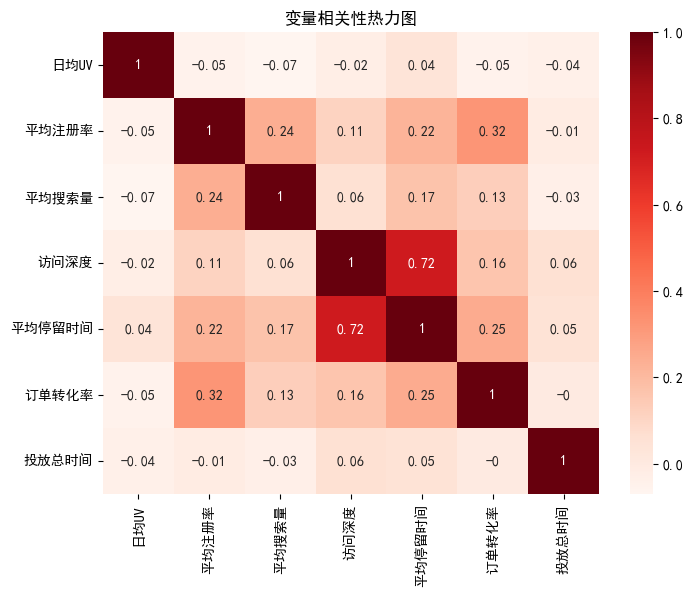

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

#只选择数值列
corr = raw_data.select_dtypes(['number']).corr().round(2)

#画热力图
plt.figure(figsize = (8,6))

sns.heatmap(corr,cmap = 'Reds',annot = True)

plt.title("变量相关性热力图")

plt.show()

结论：可以看到，“访问深度”和“平均停留时间”相关性比较高，相关性高说明两个变量在建立模型的时候，作用是一样或者效果是一样的，可以考虑组合或者删除其一

In [10]:
raw_data2 = raw_data.drop(['平均停留时间'],axis = 1)

cols = ["素材类型","广告类型","合作方式","广告尺寸","广告卖点"]
for x in cols:
    unique_data = raw_data2[x].unique()
    print(f"变量【{x}】的取值有:\n{unique_data}")
    print('-.'*20)

变量【素材类型】的取值有:
['jpg' 'swf' 'gif' 'sp']
-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.
变量【广告类型】的取值有:
['banner' 'tips' '不确定' '横幅' '暂停']
-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.
变量【合作方式】的取值有:
['roi' 'cpc' 'cpm' 'cpd']
-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.
变量【广告尺寸】的取值有:
['140*40' '308*388' '450*300' '600*90' '480*360' '960*126' '900*120'
 '390*270']
-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.
变量【广告卖点】的取值有:
['打折' '满减' '满赠' '秒杀' '直降' '满返']
-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.


In [11]:
from sklearn.preprocessing import OneHotEncoder

cols = ["素材类型","广告类型","合作方式","广告尺寸","广告卖点"]

#新版本写法
model_ohe = OneHotEncoder(sparse_output = False) #实例化独热编码器

ohe_matrix = model_ohe.fit_transform(raw_data2[cols])

#提取特征并执行转换
print(ohe_matrix[:2])

[[0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
  0. 0. 0.]
 [0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
  0. 0. 0.]]


In [12]:
#用pandas的方法
ohe_matrix1 = pd.get_dummies(raw_data2[cols])
print(ohe_matrix1.head(5))

   素材类型_gif  素材类型_jpg  素材类型_sp  素材类型_swf  广告类型_banner  广告类型_tips  广告类型_不确定  \
0     False      True    False     False         True      False     False   
1     False      True    False     False         True      False     False   
2     False      True    False     False         True      False     False   
3     False      True    False     False         True      False     False   
4     False      True    False     False         True      False     False   

   广告类型_暂停  广告类型_横幅  合作方式_cpc  ...  广告尺寸_480*360  广告尺寸_600*90  广告尺寸_900*120  \
0    False    False     False  ...         False        False         False   
1    False    False      True  ...         False        False         False   
2    False    False      True  ...         False        False         False   
3    False    False      True  ...         False        False         False   
4    False    False      True  ...         False        False         False   

   广告尺寸_960*126  广告卖点_打折  广告卖点_满减  广告卖点_满赠  广告卖点_满返  广告卖

In [13]:
#数据标准化
scale_matrix = raw_data2.iloc[:,1:7]
model_scaler = MinMaxScaler()
data_scaled = model_scaler.fit_transform(scale_matrix)
print(data_scaled.round(2))

X = np.hstack((data_scaled,ohe_matrix))

[[0.   0.18 0.02 0.01 0.12 0.66]
 [0.01 0.1  0.03 0.01 0.01 0.62]
 [0.   0.06 0.05 0.01 0.01 0.1 ]
 ...
 [0.01 0.01 0.   0.   0.   0.72]
 [0.05 0.   0.   0.   0.   0.31]
 [0.   0.   0.   0.53 0.   0.62]]


In [17]:
#通过平均轮廓系数检验得到最佳KMeans聚类模型
score_list = list() #用来储存每个K下模型的平均轮廓系数
silhouette_int = -1 #初始的平均轮廓系数阈值
for n_clusters in range(2,8): #遍历从2到5几个有限组
    model_kmeans = KMeans(n_clusters = n_clusters) #建立聚类模型对象
    labels_tmp = model_kmeans.fit_predict(X) #训练聚类模型
    silhouette_tmp = silhouette_score(X,labels_tmp) #得到每个K下的平均轮廓系数
    if silhouette_tmp > silhouette_int: # 如果当前 K 的得分比之前记录的最高分还要高
        best_k = n_clusters             # 保存当前这个最好的 K 值
        silhouette_int = silhouette_tmp # 更新最高得分记录
        best_kmeans = model_kmeans      #保存当前得分最高的模型实例（方便以后直接用来预测）
        clusters_labels_k = labels_tmp  #保存最优模型预测出的簇标签
    score_list.append([n_clusters,silhouette_tmp])
print('{:*^60}'.format('K值对应的轮廓系数：'))
print(np.array(score_list))
print('最优的K值是:{0}\n对应的轮廓系数是：{1}'.format(best_k,silhouette_int))

*************************K值对应的轮廓系数：*************************
[[2.         0.29160857]
 [3.         0.41677271]
 [4.         0.50209812]
 [5.         0.49653989]
 [6.         0.48696268]
 [7.         0.49180272]]
最优的K值是:4
对应的轮廓系数是：0.5020981194788053


In [19]:
# 将原始数据与聚类标签整合
cluster_labels = pd.DataFrame(clusters_labels_k, columns=['clusters'])  # 获得训练集下的标签信息
merge_data = pd.concat((raw_data2, cluster_labels), axis=1)  # 将原始处理过的数据跟聚类标签整合
merge_data.head()

,渠道代号,日均UV,平均注册率,平均搜索量,访问深度,订单转化率,投放总时间,素材类型,广告类型,合作方式,广告尺寸,广告卖点,clusters
0,A203,3.69,0.0071,0.0214,2.3071,0.0258,20,jpg,banner,roi,140*40,打折,2
1,A387,178.70,0.0040,0.0324,2.0489,0.0030,19,jpg,banner,cpc,140*40,满减,2
2,A388,91.77,0.0022,0.0530,1.8771,0.0026,4,jpg,banner,cpc,140*40,满减,2
3,A389,1.09,0.0074,0.3382,4.2426,0.0153,10,jpg,banner,cpc,140*40,满减,2
4,A390,3.37,0.0028,0.1740,2.1934,0.0007,30,jpg,banner,cpc,140*40,满减,2


In [20]:
# 计算每个聚类类别下的样本量和样本占比
clustering_count = pd.DataFrame(merge_data['渠道代号'].groupby(merge_data['clusters']).count()).T.rename({'渠道代号': 'counts'})  # 计算每个聚类类别的样本量
clustering_ratio = (clustering_count / len(merge_data)).round(2).rename({'counts': 'percentage'})  # 计算每个聚类类别的样本量占比
print(clustering_count)
print("#"*30)
print(clustering_ratio)

clusters    0    1    2   3
counts    313  349  154  73
##############################
clusters       0     1     2     3
percentage  0.35  0.39  0.17  0.08


In [21]:
# 计算各个聚类类别内部最显著特征值
cluster_features = []  # 空列表，用于存储最终合并后的所有特征信息
for line in range(best_k):  # 读取每个类索引
    label_data = merge_data[merge_data['clusters'] == line]  # 获得特定类的数据

    part1_data = label_data.iloc[:, 1:7]  # 获得数值型数据特征
    part1_desc = part1_data.describe().round(3)  # 得到数值型特征的描述性统计信息
    merge_data1 = part1_desc.iloc[2, :]  # 得到数值型特征的均值

    part2_data = label_data.iloc[:, 7:-1]  # 获得字符串型数据特征
    part2_desc = part2_data.describe(include='all')  # 获得字符串型数据特征的描述性统计信息
    merge_data2 = part2_desc.iloc[2, :]  # 获得字符串型数据特征的最频繁值

    merge_line = pd.concat((merge_data1, merge_data2), axis=0)  # 将数值型和字符串型典型特征沿行合并
    cluster_features.append(merge_line)  # 将每个类别下的数据特征追加到列表

#  输出完整的类别特征信息
cluster_pd = pd.DataFrame(cluster_features).T  # 将列表转化为矩阵
print('{:*^60}'.format('每个类别主要的特征:'))
all_cluster_set = pd.concat((clustering_count, clustering_ratio, cluster_pd),axis=0)  # 将每个聚类类别的所有信息合并
all_cluster_set

*************************每个类别主要的特征:*************************


,0,1,2,3
counts,313,349,154,73
percentage,0.35,0.39,0.17,0.08
日均UV,1390.013,933.015,2717.419,1904.371
平均注册率,0.003,0.003,0.005,0.003
平均搜索量,0.152,0.064,0.051,0.106
访问深度,1.168,5.916,0.947,0.943
订单转化率,0.017,0.006,0.007,0.009
投放总时间,8.199,8.77,8.529,8.217
素材类型,swf,jpg,jpg,swf
广告类型,不确定,横幅,banner,tips


       日均UV  平均注册率  平均搜索量   访问深度  订单转化率  投放总时间
0  1390.013  0.003  0.152  1.168  0.017  8.199
1   933.015  0.003  0.064  5.916  0.006  8.770
2  2717.419  0.005  0.051  0.947  0.007  8.529
3  1904.371  0.003  0.106  0.943  0.009  8.217
--------------------
[[2.56106801e-01 0.00000000e+00 1.00000000e+00 4.52443193e-02
  1.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.28712871e-01 1.00000000e+00
  0.00000000e+00 1.00000000e+00]
 [1.00000000e+00 1.00000000e+00 0.00000000e+00 8.04343455e-04
  9.09090909e-02 5.77933450e-01]
 [5.44358789e-01 0.00000000e+00 5.44554455e-01 0.00000000e+00
  2.72727273e-01 3.15236427e-02]]


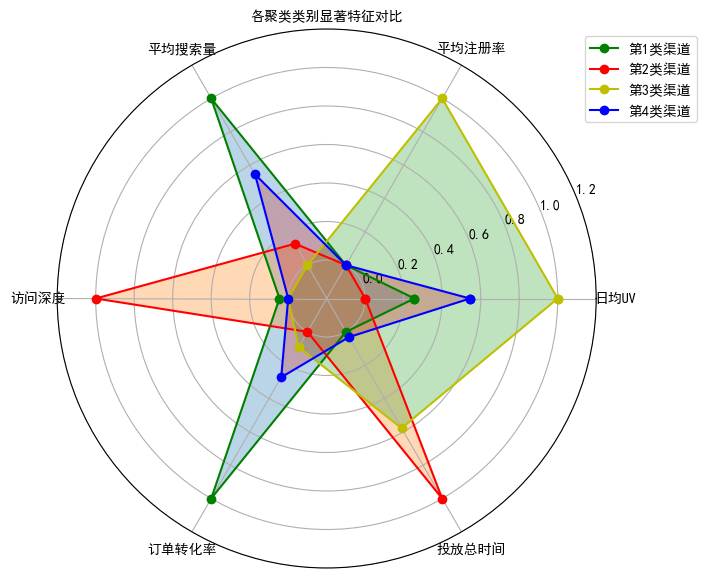

In [22]:
#各类别数据预处理
num_sets = cluster_pd.iloc[:6, :].T.astype(np.float64)  # 获取要展示的数据
num_sets_max_min = model_scaler.fit_transform(num_sets)  # 获得标准化后的数据
print(num_sets)
print('-'*20)
print(num_sets_max_min)

fig = plt.figure(figsize=(7,7))

ax = fig.add_subplot(111, polar=True)

labels = np.array(merge_data1.index)

cor_list = ['g', 'r', 'y', 'b']

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

for i in range(len(num_sets)):

    data_tmp = num_sets_max_min[i,:]

    data = np.concatenate((data_tmp, [data_tmp[0]]))

    ax.plot(angles, data, 'o-', c=cor_list[i], label="第%d类渠道"%(i+1))

    ax.fill(angles, data, alpha=0.3)

ax.set_thetagrids(
    angles[:-1]*180/np.pi,
    labels,
    fontproperties="SimHei"
)

ax.set_title("各聚类类别显著特征对比", fontproperties="SimHei")

ax.set_rlim(-0.2,1.2)

ax.legend(loc="upper right", bbox_to_anchor=(1.2,1.0))

plt.show()

数据结论
- 从案例结果来看，所有的渠道被分为4各类别，每个类别的样本量分别为：154、313、349 、73，对应占比分别为：17%、35%、39%、8%。
- 通过雷达图可以清楚地知道：
  - 类别1（索引为2类的渠道） 这类广告媒体除了访问深度和投放时间较高，其他属性较低，因此这类广告媒体效果质量较差，并且占到39%，因此这类是主题渠道之一。 业务部门要考虑他的实际投放价值。
  - 类别2（索引为1类的渠道） 这类广告媒体除了访问深度略差，在平均搜索量、日均UV、订单转化率等广告效果指标上表现良好，是一类综合效果较好的渠道。 但是日均UV是短板，较低。无法给企业带来大量的流量以及新用户，这类广告的特质适合用户转化，尤其是有关订单的转化提升。
  - 类别3（索引为0类的渠道） 这类广告媒体的显著特征是日均UV和注册率较高，其“引流”和“拉新”效果好，可以在广告媒体中定位为引流角色。 符合“广而告之”的诉求，适合“拉新”使用。
  - 类别4（索引为3类的渠道） 这类渠道各方面特征都不明显，各个流量质量和流量数量的指标均处于“中等”层次。不突出但是均衡，考虑在各场景下可以考虑在这个渠道投放广告。